# Adversarial Image Captioning Attack

## Summary of the project

#### Add "executive summary" of entire project

## Academic Background

The exploration of adversarial robustness in vision-language models has its roots in the work of Shekhar et al. (2017), who were among the first to test whether deep models for vision and language truly capture the interaction between the two modalities. Their study can be seen as an early stress test for multimodal understanding, questioning whether these models genuinely reason about images and text or simply exploit dataset regularities.

Following this, Chen et al. (2018) introduced *Show-and-Fool*, which extended the idea of adversarial attacks to image captioning models. At that time, most research focused on CNN-based image classifiers, where adversarial examples were already known to cause misclassifications through imperceptible pixel perturbations. However, captioning models pose a more complex challenge, because instead of predicting a single class label, they generate natural language sentences, and semantically similar captions can be phrased in many different ways. Simply treating each caption as a distinct class would result in an enormous output space, exceeding the number of training examples. Moreover, recurrent architectures such as RNNs had been less explored in adversarial contexts. Show-and-Fool addressed these challenges by formulating caption manipulation as an optimization problem over the input image, targeting either full sentences or specific keywords. Their results demonstrated that standard CNN-RNN captioning models could be fooled with visually imperceptible perturbations, revealing limited robustness against adversarial attacks.

Building on this line of work, Xu et al. (2019) proposed the *GEM* attack (Generalized Expectation Maximization), which reframed adversarial image captioning as a structured output learning problem with latent variables. By jointly optimizing over input perturbations and hidden word sequences using a max-margin objective, GEM achieved more controlled manipulations of the generated captions while keeping the perturbations imperceptible.

More recently, Li et al. (2024) introduced *AICAttack*, an adversarial image captioning attack that uses attention-based optimization. Their approach operates in a black-box setting, selecting candidate pixels for perturbation based on attention maps from the underlying captioning model. The idea is to subtly distort the generated captions while leaving the image visually unchanged. Li et al. use previous attacks such as Show-and-Fool and GEM as baselines and evaluate their method on attention-based captioning architectures like Show-Attend-and-Tell (Xu et al., 2016) and BLIP (Li et al., 2022).

In this project, we aim to extend this line of research to more recent model architectures. All previous works were conducted on CNN-RNN based captioning models, which are no longer the state of the art. We therefore investigate whether the AICAttack principle can be applied to Vision Transformer–based architectures, more particular the ViT-GPT2 image captioning model (Srija et al., 2025). By doing so, we explore whether we can apply AICAttack to fool modern encoder-decoder models that combine transformer-based vision and language components.

## Import Libraries, set seeds, and select GPU

In [ ]:
!pip install kagglehub
!pip install torch
!pip install torchvision
!pip install transformers
!pip install nltk
!pip install rouge_score

In [ ]:
# Importing libraries
import pandas as pd
import sys
import json
import os
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import math
import torch.nn.functional as F
from torch.optim import Adam
import torchvision.transforms as transforms
from transformers import AutoTokenizer, ViTImageProcessor, VisionEncoderDecoderModel
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import random
import traceback
from collections import Counter
from tqdm import tqdm

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
# GPU setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

## Load Flickr8k Dataset & Basic Exploratory Data Analysis

Flickr8k is a compact image captioning dataset consisting of 8k images collected from the Flickr photo-sharing platform. Each image is paired with five human-written captions, resulting in a total of 40k descriptive sentences that capture everyday scenes and interactions. Compared to large-scale resources like COCO, Flickr8k is significantly smaller yet still widely used for benchmarking captioning models due to its clean annotations and manageable size. Lin et al. (2014) also tested their AIC Attack on the Flickr8k dataset, allowing for comparable results.

Because Flickr8k can be loaded into memory with relatively low computational cost, it is well suited for experiments where the primary goal is to evaluate model behaviour. In our project, this dataset serves to examine how well AIC-style adversarial attacks transfer to transformer-based captioning models. We explicitly chose Flickr8k Dataset as the baseline instead of COCO as the ViT-GPT model was pretrained on the COCO dataset and evaluating the performance on the COCO dataset would result in data leakage. The dataset can be found on kaggle: https://www.kaggle.com/datasets/sayanf/flickr8k

In [ ]:
data_path = kagglehub.dataset_download("sayanf/flickr8k")
print("Dataset downloaded to:", data_path)

# The dataset structure is:
# data_path/Flickr8k_Dataset/*.jpg
# data_path/Flickr8k_text/Flickr8k.token.txt

images_dir = os.path.join(data_path, "Flickr8k_Dataset")
captions_file = os.path.join(data_path, "Flickr8k_text", "Flickr8k.token.txt")

print("Images dir:", images_dir)
print("Captions file:", captions_file)

In [ ]:
def load_flickr8k_captions(captions_file):
    """ Load captions from Flickr8k.token.txt file. """
    captions = {}
    with open(captions_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Format: filename#0<TAB>Caption…
            fname, caption = line.split("\t")
            img_name = fname.split("#")[0]  # remove #0,#1,#2,#3,#4

            captions.setdefault(img_name, []).append(caption)

    return captions

captions = load_flickr8k_captions(captions_file)
img_names = sorted(captions.keys())

print(f"Loaded {len(img_names)} images with captions.")

In [ ]:
def get_image(idx):
    """ Load image and its 5 captions by index."""
    img_name = img_names[idx]
    img_path = os.path.join(images_dir, img_name)

    if not os.path.exists(img_path):
        raise FileNotFoundError(img_path)

    img = Image.open(img_path).convert("RGB")
    return img, captions[img_name]

In [ ]:
# Displaying sample image for validation
idx = 20
img, gt_caps = get_image(idx)

print("Filename:", img_names[idx])
print("Captions:")
for c in gt_caps:
    print("  -", c)

plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
num_images = len(img_names)
num_captions = sum(len(v) for v in captions.values())

print(f"Number of images: {num_images}")
print(f"Total captions: {num_captions}")
print(f"Average captions per image: {num_captions / num_images:.2f}")

In [ ]:
caption_lengths = [len(c.split()) for caps in captions.values() for c in caps]
print("Caption length (words):")
print(f"Min length: {min(caption_lengths)}")
print(f"Max length: {max(caption_lengths)}")
print(f"Average length: {np.mean(caption_lengths):.2f}")

plt.figure()
plt.hist(caption_lengths, bins=20)
plt.title("Caption length distribution")
plt.xlabel("Words per caption")
plt.ylabel("Frequency")
plt.show()

In [ ]:
all_words = [w for caps in captions.values() for c in caps for w in c.lower().split()]
word_counts = Counter(all_words)

print(f"Vocabulary size (unique tokens): {len(word_counts)}")
print("Most common 15 words:")
for w, cnt in word_counts.most_common(15):
    print(f"{w}: {cnt}")

## Load SAT Model 

The Show, Attend and Tell (SAT) model introduced by Xu et al. (2015) is one of the early and influential approaches to attention-based image captioning. Its main contribution was the use of a visual attention mechanism that allows the model to focus on different regions of an image while generating each word. This makes the captioning process more accurate and also interpretable, since the resulting attention maps show what the model considered relevant at each step. SAT is also used as a baseline in the AICAttack paper (Li et al., 2024), where these attention maps are leveraged to identify sensitive pixels for adversarial perturbations.

SAT follows a CNN–RNN architecture with an integrated attention module:

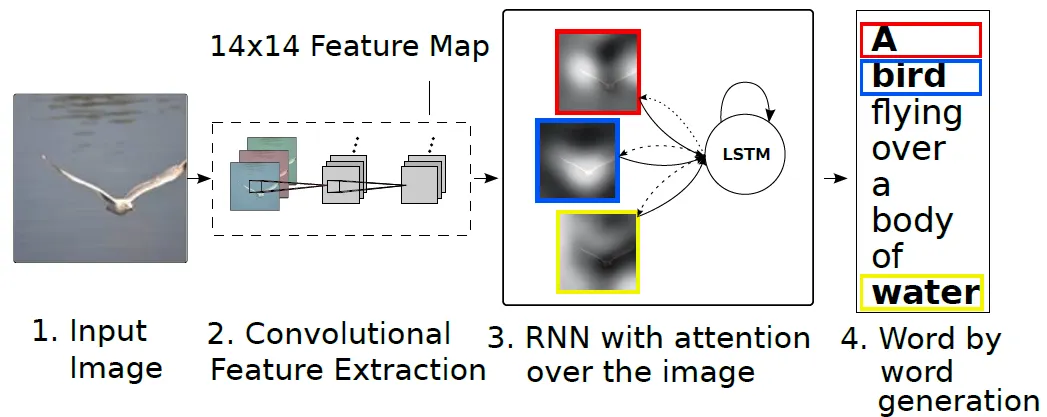

**Encoder (ResNet-101)**
- Pretrained on ImageNet
- Extracts visual features from the input image
- Outputs a 2048 × 14 × 14 feature map (PyTorch: channels-first)
- Corresponds to 196 spatial locations, each representing a semantic region of the image
- Later reshaped to (batch_size, 196, 2048) before being passed to the attention mechanism

**Attention Mechanism**
- Computes soft attention weights for each of the 196 encoder locations
- Creates a weighted visual context vector at each decoding step
- Uses a gating mechanism as described in Xu et al. (2015) to refine attention
- Produces word-level attention maps that show which image regions influenced each generated word

**Decoder (LSTM)**
- Takes the previous word embedding and the attended context vector as input
- Generates one word per timestep
- Uses beam search to explore multiple caption candidates (typically beam size 5)
- Vocabulary size depends on preprocessing (our implementation uses around 9.5k words from COCO)

The version of SAT used in our code was trained on the MSCOCO 2014 dataset. The pretrained checkpoint was downloaded from the AICAttack GitHub repository (https://github.com/UTSJiyaoLi/AICAttack), while the model code and supporting modules (e.g., models.py) were taken from the official PyTorch image captioning tutorial repository (https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning).

In [ ]:
# Older PyTorch Adam optimizer checkpoints are sometimes incompatible with newer PyTorch versions
# To prevent this, we temporarily patch Adam.__setstate__ to avoid errors when loading such checkpoints

# Save original state to be able to restore it later
_original_adam_setstate = Adam.__setstate__

# Define a patched version that ensures required attributes exist
def patched_setstate(self, state):
    for attr in ["defaults", "state", "param_groups"]:
        if not hasattr(self, attr):
            setattr(self, attr, {} if attr != "param_groups" else [])
    try:
        _original_adam_setstate(self, state)
    except AttributeError:
        pass

# Apply patch to that checkpoint loading works
Adam.__setstate__ = patched_setstate

# Load checkpoint
sat_checkpoint = torch.load(
    "./checkpoint/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar",
    map_location=device,
    weights_only=False
)

# Restore original Adam.__setstate__ method
Adam.__setstate__ = _original_adam_setstate

# Load SAT model components
sat_encoder = sat_checkpoint["encoder"].to(device).eval()
sat_decoder = sat_checkpoint["decoder"].to(device).eval()

# Load SAT word map
with open("./checkpoint/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json", "r") as f:
    sat_word_map = json.load(f)
sat_rev_word_map = {v: k for k, v in sat_word_map.items()}

The following function performs the caption generation using the pretrained SAT model. For preprocessing, the input image is resized to 256×256, converted to RGB if necessary, scaled to the [0,1] range, and normalized with ImageNet statistics so it matches the ResNet-101 encoder described above. The encoded image features are then passed to the SAT decoder, which works as outlined above: The decoder applies the learned attention mechanism over the 14×14 spatial feature grid and generates one word at a time using the LSTM.

Caption generation is implemented with beam search, where the function keeps the top-k partial sequences at each timestep and updates them based on the decoder’s log-probabilities. As in the standard SAT approach, each decoding step also produces an attention map showing which spatial regions contributed to the predicted word, and these maps are stored throughout the sequence.

The function returns the highest-scoring caption together with the corresponding attention weights and the token list. Since it directly follows the SAT pipeline in the AICAttack paper, this implementation remains compatible with existing sgrvinod SAT checkpoints and behaves consistently with the original model design.

In [ ]:
# SAT caption generation with attention

def sat_caption(image, beam_size=3):
    """Generate caption using SAT model."""
    
    # Preprocess if not already a tensor
    if isinstance(image, Image.Image):
        # Resize image and convert to Numpy array
        img = np.array(image.resize((256, 256)))
        
        # If grayscale, repeat the channel 3 times
        if len(img.shape) == 2:
            img = np.stack([img]*3, axis=2)
            
        # Transpose for PyTorch
        img = img.transpose(2, 0, 1) / 255.0
        img = torch.FloatTensor(img).to(device)
    else:
        img = image.to(device)
    
    # Normalization required for ResNet encoder
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    img = normalize(img)
    
    with torch.no_grad():
        k = beam_size # Beam size, k candidates are kept at each step
        vocab_size = len(sat_word_map)
        
        # Encode
        img = img.unsqueeze(0) # Add batch dimension
        encoder_out = sat_encoder(img)
        enc_image_size = encoder_out.size(1)
        encoder_dim = encoder_out.size(3)
        encoder_out = encoder_out.view(1, -1, encoder_dim) # Flatten the spatial grid
        num_pixels = encoder_out.size(1)
        encoder_out = encoder_out.expand(k, num_pixels, encoder_dim) # Duplicate encoded image k times for k beams
        
        # Initialize
        k_prev_words = torch.LongTensor([[sat_word_map["<start>"]]] * k).to(device) # Start each beam with start token
        seqs = k_prev_words # Store sequences generated so far
        top_k_scores = torch.zeros(k, 1).to(device) # Cumulative log-probability scores for each beam
        seqs_alpha = torch.ones(k, 1, enc_image_size, enc_image_size).to(device) # Store attention weights
        
        complete_seqs = [] # Completed sequences
        complete_seqs_alpha = [] # Completed sequences' attention weights
        complete_seqs_scores = [] # Scores for completed sequences
        
        step = 1
        h, c = sat_decoder.init_hidden_state(encoder_out) # Initialize hidden state
        
        # Beam search loop to generate one word per time step
        while True:
            embeddings = sat_decoder.embedding(k_prev_words).squeeze(1) # Embed previous words
            awe, alpha = sat_decoder.attention(encoder_out, h) # Attention weighted encoding
            alpha = alpha.view(-1, enc_image_size, enc_image_size) # Reshape attention weights
            gate = sat_decoder.sigmoid(sat_decoder.f_beta(h))
            awe = gate * awe
            h, c = sat_decoder.decode_step(torch.cat([embeddings, awe], dim=1), (h, c)) # LSTM decode step
            
            scores = sat_decoder.fc(h)
            scores = F.log_softmax(scores, dim=1) # Log softmax over vocabulary
            scores = top_k_scores.expand_as(scores) + scores # Add previous scores
            
            if step == 1:
                top_k_scores, top_k_words = scores[0].topk(k, 0, True, True) # For first prediction, choose top k words from first beam
            else:
                top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True) # After first step, pick top k from all beams
            
            # Determine which beam each word came from
            prev_word_inds = top_k_words // vocab_size
            next_word_inds = top_k_words % vocab_size
            
            # Append
            seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1)
            seqs_alpha = torch.cat([seqs_alpha[prev_word_inds],
                                    alpha[prev_word_inds].unsqueeze(1)], dim=1)
            
            # Identify complete and incomplete sequences
            incomplete_inds = [ind for ind, next_word in enumerate(next_word_inds)
                              if next_word != sat_word_map["<end>"]]
            complete_inds = list(set(range(len(next_word_inds))) - set(incomplete_inds))
            
            if len(complete_inds) > 0:
                complete_seqs.extend(seqs[complete_inds].tolist())
                complete_seqs_alpha.extend(seqs_alpha[complete_inds].tolist())
                complete_seqs_scores.extend(top_k_scores[complete_inds])
            
            # Reduce beam size if some sequences are complete
            k -= len(complete_inds)
            if k == 0 or step > 50:
                break
            
            # Update everything for next step, keeping only incomplete sequences
            seqs = seqs[incomplete_inds]
            seqs_alpha = seqs_alpha[incomplete_inds]
            h = h[prev_word_inds[incomplete_inds]]
            c = c[prev_word_inds[incomplete_inds]]
            encoder_out = encoder_out[prev_word_inds[incomplete_inds]]
            top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
            k_prev_words = next_word_inds[incomplete_inds].unsqueeze(1)
            
            step += 1
    
    # Get best sequence with highest total score
    i = complete_seqs_scores.index(max(complete_seqs_scores))
    seq = complete_seqs[i]
    alphas = complete_seqs_alpha[i]
    
    words = [sat_rev_word_map[ind] for ind in seq 
             if ind not in {sat_word_map["<start>"], sat_word_map["<end>"], sat_word_map["<pad>"]}]
    
    return " ".join(words), alphas, words

## Load ViT-GPT2

The ViT - GPT2 Model follows a Vision Encoder Decoder Architecture, combining ViT as encoder and GPT2 as decoder into a single end-to-end image captioning system. Its architecture is displayed in the image below and characteristics of encoder and decoder are summarized below. The model is fine-tuned on the **MS COCO** dataset to learn cross-attention weights. In this project, we examine to what extent an AIC Attack pipeline as implmemented on the SAT model can be applied to the transformer-based ViT-GPT2 Model. 

<u>Vision Transformer (Encoder):</u>

The Vision Transformer (ViT) is based on Dosovitskiy et al. (2020), *An Image Is Worth 16×16 Words*. ViT splits the input image into fixed-size patches, linearly embeds each patch, adds positional embeddings, and processes the patch sequence via transformer encoder layers. This yields a sequence of global visual features that represent the image content.
In the ViT-GPT2 captioning architecture, ViT effectively captures global structure and long-range dependencies across the image

<u>Transformer Decoder (GPT):</u>

The decoder follows the GPT-2 architecture (Radford et al., 2019), a pretrained causal language model on web text. Given ViT’s visual embeddings as cross-attention memory, GPT-2 generates captions autoregressively, attending both to the image features and previously generated tokens


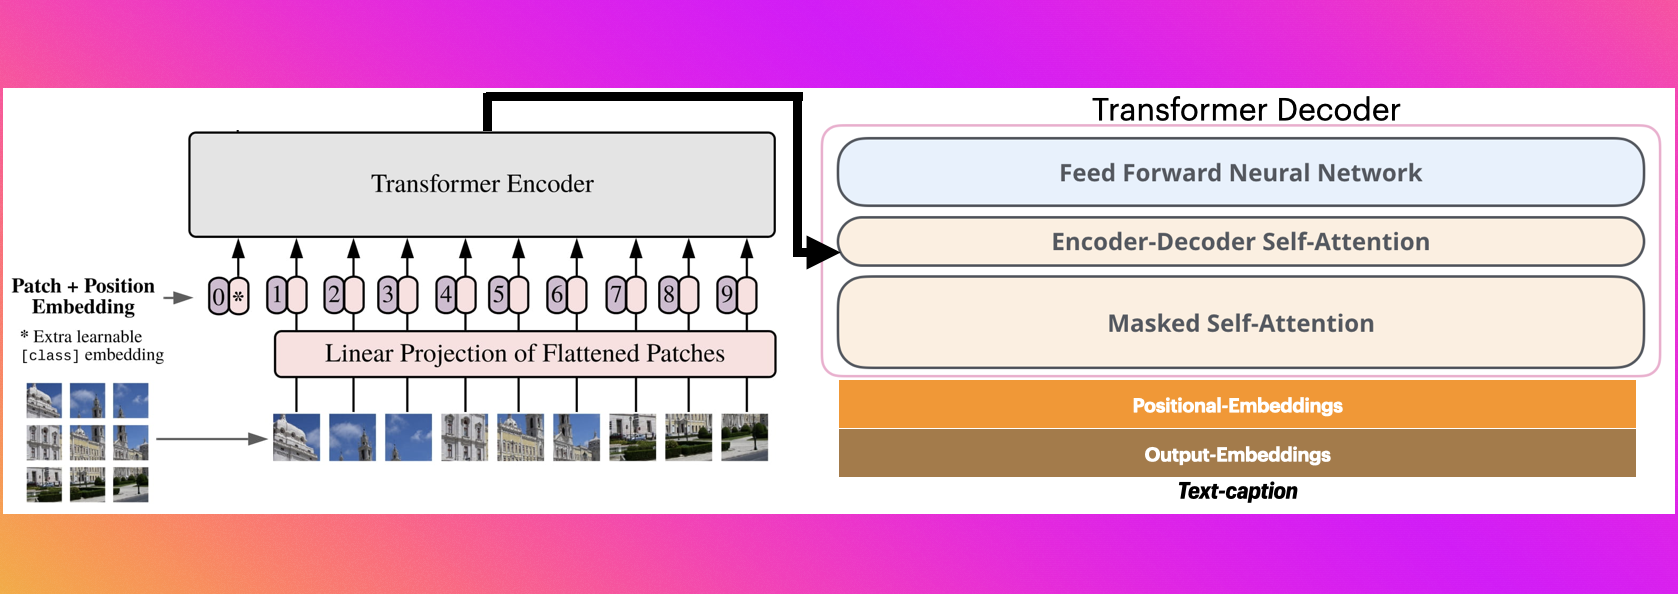

In [ ]:
# Loading pre-trained transformer model for image captioning
model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(
    model_name,
    attn_implementation="eager").to(device)

feature_extractor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

model.eval()

print(f"Loaded model: {model_name}")
# Attention implementation set to eager to ensure cross-attention weights are available
print(f"Decoder attention implementation: {model.config.decoder._attn_implementation}")

In [ ]:
@torch.no_grad()  # ensure no gradients are computed
def generate_caption_and_attention(img, max_length=16):
    """
    Generate a caption for a PIL image and return:
    - caption (str)
    - cross_attentions (list of tensors)
    - encoder_hidden_states (tensor)
    """
    # Image -> pixel_values
    pixel_values = feature_extractor(images=img, return_tensors="pt").pixel_values.to(device)

    # Encode image
    encoder_outputs = model.encoder(pixel_values=pixel_values)
    encoder_hidden_states = encoder_outputs.last_hidden_state  # [1, 197, hidden_dim]

    # Generate caption ids
    generated_ids = model.generate(
        pixel_values,
        max_length=max_length,
        num_beams=1)

    # Run decoder once over full sequence to get cross-attentions
    decoder_outputs = model.decoder(
        input_ids=generated_ids,
        encoder_hidden_states=encoder_hidden_states,
        output_attentions=True,
        return_dict=True,
        use_cache=False)

    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    return caption, decoder_outputs.cross_attentions, encoder_hidden_states


The function below aggregates cross-attention from the last decoder layer by **averaging over all attention heads** and **all caption tokens**. This yields a single attention score per encoder image token. After removing the CLS token, the patch-level scores (196 values) are reshaped into a 14×14 grid and upsampled to the image resolution. The resulting heatmap visualizes which spatial regions of the image the captioning model focused on while generating the entire caption.

In [ ]:
# Function to comptue: where does the model attend in the image while generating the entire caption? 
# To calculate this, we aggregate cross-attention weights over all heads and all generated tokens.
def aggregate_cross_attention(cross_attentions, img_size, patch_size=14):
    """
    Aggregate cross-attention over heads and tokens into a 2D heatmap
    in image resolution (sentence-based aggregation). 
    """
    # Take last decoder layer (most informative)
    last_layer = cross_attentions[-1]          # dimensionality: [1, num_heads, tgt_len, src_len]; tgt_len = num generated tokens; src_le = num image patches + 1 (CLS)
    last_layer = last_layer.squeeze(0)         # dropping batch dimension

    # Average over heads and decoder tokens
    avg_over_heads = last_layer.mean(dim=0)    # [tgt_len, src_len]: one unified attention map per caption token
    avg_over_tokens = avg_over_heads.mean(dim=0)  # [src_len]: one unified attention map for entire caption;
    #avg_over_tokens: across entire caption, how much attention was paid to each image patch (and CLS token)?

    # Drop CLS token and keep only patch tokens
    patch_attention = avg_over_tokens[1:]      # dimensionality: [patch_size^2]

    # Reshape to patch grid
    attention_map = patch_attention.reshape(patch_size, patch_size).cpu().numpy()

    # Normalize to [0, 1]
    attention_map -= attention_map.min()
    denom = attention_map.max() if attention_map.max() > 0 else 1e-8
    attention_map /= denom

    # Upsample to original image size to display attention heatmap
    w, h = img_size
    attn_img = Image.fromarray((attention_map * 255).astype(np.uint8))
    attn_resized = attn_img.resize((w, h), resample=Image.BICUBIC)

    return np.array(attn_resized) / 255.0


## Visualisation of Example Image & Attention Comparison: SAT & ViT-GPT2

#### ViT Visualization Functions

In [ ]:
def show_image_and_attention(img, caption, attention_heatmap):
    """Plot original image, attention heatmap, and overlay."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    attention_heatmap = np.array(attention_heatmap, dtype=np.float32)

    # Original image
    axes[0].imshow(img)
    axes[0].set_title(f"Original image\nCaption: '{caption}'", fontsize=10)
    axes[0].axis("off")

    # Heatmap only
    axes[1].imshow(attention_heatmap, cmap="hot")
    axes[1].set_title("Cross-attention heatmap\n(sentence-based)", fontsize=10)
    axes[1].axis("off")

    # Overlay
    axes[2].imshow(img)
    axes[2].imshow(attention_heatmap, cmap="hot", alpha=0.5)
    axes[2].set_title("Attention overlay\n(red = high attention)", fontsize=10)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:

def visualize_vit_token_attention(img, cross_attentions, caption, patch_size=14):
    """
    Visualize per-token cross-attention for the ViT-GPT2 model.
    Uses the last decoder layer, averaged over heads, and overlays one heatmap per word on the original image.
    """
    # Last decoder layer averaged over heads
    last_layer = cross_attentions[-1].squeeze(0)   # [num_heads, tgt_len, src_len]
    num_heads, tgt_len, src_len = last_layer.shape
    avg_over_heads = last_layer.mean(dim=0)

    # Drop CLS token on the source side -> [tgt_len, patch_size^2]
    patch_attn = avg_over_heads[:, 1:]
    words = caption.split()
    n_words = min(len(words), tgt_len)
    cols = 5
    rows = math.ceil(n_words / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten() if n_words > 1 else [axes]

    w, h = img.size

    for t in range(n_words):
        word = words[t]
        attn_vec = patch_attn[t]
        attn_map = attn_vec.reshape(patch_size, patch_size).cpu().numpy()
        # normalize to [0, 1]
        attn_map -= attn_map.min()
        denom = attn_map.max() if attn_map.max() > 0 else 1e-8
        attn_map /= denom

        # upsample to image size
        attn_img = Image.fromarray((attn_map * 255).astype(np.uint8))
        attn_resized = attn_img.resize((w, h), resample=Image.BICUBIC)
        attn_resized = np.array(attn_resized) / 255.0

        axes[t].imshow(img)
        axes[t].imshow(attn_resized, cmap="gray", alpha=0.7)
        axes[t].set_title(word, fontsize=12)
        axes[t].axis("off")

    # Turn off any leftover axes
    for t in range(n_words, len(axes)):
        axes[t].axis("off")

    plt.tight_layout()
    plt.show()


#### SAT Visualization Functions

In [ ]:
caption, alphas, words = sat_caption(img)
print(f"SAT: {caption}\n")

In [ ]:
def visualize_sat_attention(image, alphas, words):
    """Visualize per-word attention."""
    img_resized = image.resize((14*24, 14*24)) # Resize for visualization

    n_words = len(words) # Number of words in caption
    cols = 5
    rows = int(np.ceil(n_words / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    axes = axes.flatten() if n_words > 1 else [axes]
    
    for t, (word, alpha) in enumerate(zip(words, alphas[1:n_words+1])): # Skip start token
        alpha_np = np.array(alpha)
        alpha_resized = F.interpolate(
            torch.FloatTensor(alpha_np).unsqueeze(0).unsqueeze(0),
            size=(14*24, 14*24),
            mode='bilinear'
        ).squeeze().numpy()
        
        axes[t].imshow(img_resized)
        axes[t].imshow(alpha_resized, cmap='gray', alpha=0.7)
        axes[t].set_title(word, fontsize=12)
        axes[t].axis('off')
    
    for t in range(n_words, len(axes)):
        axes[t].axis('off')
    
    plt.tight_layout()
    plt.show()
    
visualize_sat_attention(img, alphas, words)

In [ ]:
#SAT attention model visualization sentence level
alphas_tensor = torch.FloatTensor(alphas[1:len(words)+1])  # Skip start token
attention_agg = alphas_tensor.sum(dim=0)  # sum across words

# Normalize
attention_agg = attention_agg.numpy()
attention_agg -= attention_agg.min()
denom = attention_agg.max() if attention_agg.max() > 0 else 1e-8
attention_agg /= denom

# Upsample to original image size
w, h = img.size
attn_img = Image.fromarray((attention_agg * 255).astype(np.uint8).reshape(14, 14))
attn_resized = attn_img.resize((w, h), resample=Image.BICUBIC)
sat_attention_heatmap = np.array(attn_resized) / 255.0
show_image_and_attention(img, sat_caption, sat_attention_heatmap)

#### Example Image

In [ ]:
img, gt_caps = get_image(idx)

print(f"Image index: {idx}")
print("\nGround-truth captions:")
for cap in gt_caps:
    print(f"  - {cap}")

In [ ]:
# SAT visualizations
sat_caption, alphas, words = sat_caption(img)

# SAT token-level attention
visualize_sat_attention(img, alphas, words)
# SAT sentence-level attention
alphas_tensor = torch.FloatTensor(alphas[1:len(words)+1])
attention_agg = alphas_tensor.sum(dim=0)

attention_agg = attention_agg.numpy()
attention_agg -= attention_agg.min()
denom = attention_agg.max() if attention_agg.max() > 0 else 1e-8
attention_agg /= denom

w, h = img.size
attn_img = Image.fromarray((attention_agg * 255).astype(np.uint8).reshape(14, 14))
attn_resized = attn_img.resize((w, h), resample=Image.BICUBIC)
sat_attention_heatmap = np.array(attn_resized) / 255.0

show_image_and_attention(img, sat_caption, sat_attention_heatmap)

In [ ]:
# ViT-GPT2 visualizations
vit_caption, cross_attentions, _ = generate_caption_and_attention(img)
vit_attention_heatmap = aggregate_cross_attention(cross_attentions, img.size)
# ViT-GPT2 sentence-level
show_image_and_attention(img, vit_caption, vit_attention_heatmap)
# ViT-GPT2 token-level
visualize_vit_token_attention(img, cross_attentions, vit_caption)

## Attack Pipeline

- Differential evolution (Storn & Price, 1997) population based optimization algorithm for solving complex multi-modal optimization problems
- Li et al. use differential evolution as an optimization algorithm to adjust adversarial perturbations so that alterations are imperceptible and highly effective

To test whether the AICAttack principle transfers to transformer-based architectures, we implemented an adapted attack pipeline for the ViT-GPT2 model. The original AICAttack (Li et al, 2024) operates in a black-box setting, meaning the internal gradients and parameters of the attacked model are not accessible. This rules out attacks such as FGSM and requires a population-based optimization method that can iteratively explore perturbations based on model outputs alone. We start our attack pipeline by defining the functions to compute BLEU and Rouge scores. 

The metrics are used to quantify how strongly our adversarial perturbations affect the generated captions, while BLEU (Papineni et al., 2002) measures how many n-grams from a candidate sentence appear in the reference sentence(s). It is a precision metric, where a high value indicates that most n-grams produced in the model are present in the human references/the generated caption on the original image. In our setup, we compute sentence-level BLEU with smoothing for n=1, 2, and 4.For each image, we compare the clean caption and the adversarial caption against the same ground-truth references and then analyse how BLEU changes under perturbation.

Rouge (Lin, 2004) focuses on recall, that is, how many n-grams from the reference sentences are recoverd in the candidate. While BLEU penalises irrelevant n-grams, Rouge penalises missing content. We compute Rouge-1 and Rouge-2, which measure the overlap in unigrams and bigrams between generated and reference captions. As with BLEU, we comprare scores for clean and adversarial captions on a per-image basis.

Using both BLEU and Rouge allows us to capture different aspects of robustness. BLEU only may not fully capture human language's semantic and contextual nuances and might not always correlate with human judgement (Li et al, 2024). Rouge provide a more complete picture of how severely the attack reduces the caption quality.

In [ ]:
def compute_all_bleu_scores(reference_captions, predicted_caption):
    """Calculate BLEU1, BLEU2, and BLEU4."""
    references = [ref.split() for ref in reference_captions]
    prediction = predicted_caption.split()
    smoothing = SmoothingFunction().method4
    bleu1 = sentence_bleu(references, prediction, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = sentence_bleu(references, prediction, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu4 = sentence_bleu(references, prediction, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)
    return bleu1, bleu2, bleu4

In [ ]:
def compute_rouge_scores(reference_captions, predicted_caption):
    """Calculate ROUGE1 and ROUGE2."""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=True)
    
    rouge1_scores = []
    rouge2_scores = []
    
    for ref in reference_captions:
        scores = scorer.score(ref, predicted_caption)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
    
    # Take the best score
    rouge1 = max(rouge1_scores) if rouge1_scores else 0.0
    rouge2 = max(rouge2_scores) if rouge2_scores else 0.0
    
    return rouge1, rouge2

In [ ]:
def prepare_image_fixed_size(img_pil, size=224):
    """Resize Image to a fixed size."""
    img_resized = img_pil.resize((size, size), Image.BICUBIC)
    # Convert to [C, H, W] array in range [0, 255]
    img_array = torch.tensor(np.array(img_resized)).permute(2, 0, 1).float()
    return img_array, img_resized

Function aggregates attentions across heads and tokens to get cross-attention for whole caption. Difference to previous attention calculation: enforcing target size of 224x224 so attention aligns with **perturbed image tensor** later.

In [ ]:
def aggregate_cross_attention_fixed_size(cross_attentions, target_size=224, patch_size=14):
    """Aggregate attention to a fixed size."""
    last_layer = cross_attentions[-1].squeeze(0)
    avg_over_heads = last_layer.mean(dim=0)
    avg_over_tokens = avg_over_heads.mean(dim=0)
    patch_attention = avg_over_tokens[1:]
    attention_map = patch_attention.reshape(patch_size, patch_size).cpu().numpy()
    attention_map -= attention_map.min()
    denom = attention_map.max() if attention_map.max() > 0 else 1e-8
    attention_map /= denom
    attn_img = Image.fromarray((attention_map * 255).astype(np.uint8))
    attn_resized = attn_img.resize((target_size, target_size), resample=Image.BICUBIC)
    return np.array(attn_resized) / 255.0

In [ ]:
# Attention selection but for fixed size 224x224 images; output always shape (224,224)
def aggregate_cross_attention_fixed_size(cross_attentions, target_size=224, patch_size=14):
    """Aggregate attention to fixed size heatmap."""
    last_layer = cross_attentions[-1].squeeze(0) # drop batch dimension
    avg_over_heads = last_layer.mean(dim=0) # average over heads
    avg_over_tokens = avg_over_heads.mean(dim=0) # average over tokens
    patch_attention = avg_over_tokens[1:] # remove CLS
    
    attention_map = patch_attention.reshape(patch_size, patch_size).cpu().numpy() # reshape to patch grid
    attention_map -= attention_map.min() # normalizing attention map
    denom = attention_map.max() if attention_map.max() > 0 else 1e-8
    attention_map /= denom
    
    attn_img = Image.fromarray((attention_map * 255).astype(np.uint8))
    attn_resized = attn_img.resize((target_size, target_size), resample=Image.BICUBIC)  # INTERPOLATION: upsampling to 224x224 because evolutionary perutrbations need pixel grid, not 14x14 patches
    
    return np.array(attn_resized) / 255.0

Following Li et al., we use the model's attention maps to identify semantically important regions that most influence the generated caption. Specifically, the attention weights from the encoder-decoder cross-attention layer are averaged over all attention heads and normalized to form a distribution across image patches. From this map, we select the top 50% of pixels as the candidate region for perturbations. This approach ensures that the attack focuses on the visually and semantically important areas while keepingthe perturbations imperceptible.

In [ ]:
def select_candidate_region(attention_heatmap, percentage=0.5):
    """Choose the top 50% quantile of attention pixels as the candidate region."""
    H, W = attention_heatmap.shape
    flat_attention = attention_heatmap.flatten()
    sorted_indices = np.argsort(flat_attention)[::-1]
    k = int(len(flat_attention) * percentage)
    top_indices = sorted_indices[:k]
    candidate_pixels = []
    for idx in top_indices:
        y = idx // W
        x = idx % W
        candidate_pixels.append((y, x))
    return candidate_pixels

Function below is used in Differential Evolution to select the actual pixels from candidate pixels to perturb the image. We define two potential methods to select these pixels: 
-   topk: deterministic and simply returns the absolute top num_pixels (i.e. top 100 attention pixels)
-   weighted: each candidate pixel is selected with probability proportional to its attention value; bringing diversity into attack initialization

In our DE implementation, we use the weighted method as we found out that the perturbations are more effective and less perceptible.

In [ ]:
def select_attack_pixels(candidate_pixels, attention_heatmap, num_pixels, method='topk'):
    """choose top k pixel with highest attention or sample k pixels from the candidate area based on attention values."""
    if method == 'topk':
        return candidate_pixels[:num_pixels]
    elif method == 'weighted':
        weights = np.array([attention_heatmap[y, x] for y, x in candidate_pixels])
        weights = weights / weights.sum()
        indices = np.random.choice(len(candidate_pixels), size=num_pixels, replace=True, p=weights)
        return [candidate_pixels[i] for i in indices]
    else:
        raise ValueError(f"Unknown method: {method}")

In [ ]:
def apply_perturbation(img_array, perturbations, pixel_coords):
    """
    Apply RGB deltas to specified pixels in the image.
    """
    perturbed = img_array.clone()
    for i, (y, x) in enumerate(pixel_coords):
        for c in range(3):
            # Additive Perturbation
            new_val = perturbed[c, y, x] + perturbations[i, c]
            perturbed[c, y, x] = torch.clamp(new_val, 0, 255)
    return perturbed


Function below is used to receive caption. Because input is img_array of perturbed image, the normalization is handled manually here and batch dimension is added to fit what ViT expects.

In [ ]:
@torch.no_grad()
def generate_caption_manual_norm(img_array, model, device, max_length=16):
    """
    Generate caption
    """
    # Convert to [0, 1]
    img_normalized = img_array / 255.0

    # Normalize with ViT values (mean and std from ImageNet)
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1).to(device)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1).to(device)
    img_normalized = img_normalized.to(device)
    img_normalized = (img_normalized - mean) / std

    # Add batch dimension
    pixel_values = img_normalized.unsqueeze(0)  # [1, 3, H, W]
    
    # Generate caption
    generated_ids = model.generate(pixel_values, max_length=max_length, num_beams=1)
    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return caption

To optimize the perturbation, we use Differential Evolution (Storn & Prince, 1997), which is a population-based optimization algorithm. At a high level, DE maintains a population of candidate solutions, where each candidate represents one possible perturbation vector \(\delta\) applied to the selected pixels from the candidate region. In each generation, the algorithm
1. **Mutates** existing candidates by combining three randomly chosen individualsfrom the population.
2. **Recombines** the mutated vector with the original candidate through a crossover step.
3. **Selects** between the old and the solution based on a fitness function. Only the better one gets into the next generation.

The goal is that the perturbations remain visually imperceptible but at the same time highly effective at changing the generated caption. DE searches over the space of possible perturbations, guided solely by how much the resulting captions diverge from the one on the clean image according to our fitness function.

In [ ]:
def differential_evolution_attack_extended(
    img_pil_original,
    pixel_coords,
    gt_captions,
    model,
    device,
    img_size=224,
    pop_size=20,
    max_iter=5,
    F=0.5,
    delta_range=50,
    verbose=True
):
    """
    Differential Evolution Attack with BLEU-1, BLEU-2, BLEU-4, ROUGE-1, ROUGE-2 tracking.
    """
    num_pixels = len(pixel_coords)

    # Resize to fixed size
    if verbose:
        print(f"\nResizing image from {img_pil_original.size} to {img_size}×{img_size}")
    img_array, img_pil_resized = prepare_image_fixed_size(img_pil_original, size=img_size)
    
    # Original Scores
    original_caption = generate_caption_manual_norm(img_array, model, device)
    orig_bleu1, orig_bleu2, orig_bleu4 = compute_all_bleu_scores(gt_captions, original_caption)
    orig_rouge1, orig_rouge2 = compute_rouge_scores(gt_captions, original_caption)
    
    # Initialize Population
    population = []
    for _ in range(pop_size):
        deltas = np.random.randint(-delta_range, delta_range+1, size=(num_pixels, 3))
        population.append(deltas)
    
    # Evaluate initial population
    population_fitness = []
    for individual in population:
        perturbed = apply_perturbation(img_array, individual, pixel_coords)
        caption = generate_caption_manual_norm(perturbed, model, device)
        _, _, bleu4 = compute_all_bleu_scores(gt_captions, caption)
        population_fitness.append(bleu4)
    
    # Track best
    best_idx = np.argmin(population_fitness)
    best_individual = population[best_idx].copy()
    best_bleu4 = population_fitness[best_idx]
    best_caption = generate_caption_manual_norm(
        apply_perturbation(img_array, best_individual, pixel_coords),
        model, device
    )
    best_bleu1, best_bleu2, _ = compute_all_bleu_scores(gt_captions, best_caption)
    best_rouge1, best_rouge2 = compute_rouge_scores(gt_captions, best_caption)
    
    # DE Loop
    for gen in range(1, max_iter + 1):
        new_population = []
        new_fitness = []
        
        for i in range(pop_size):
            candidates = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(candidates, size=3, replace=False)
            mutant = population[r1] + F * (population[r2] - population[r3])
            mutant = np.clip(mutant, -delta_range, delta_range).astype(np.int32)
            
            perturbed = apply_perturbation(img_array, mutant, pixel_coords)
            caption = generate_caption_manual_norm(perturbed, model, device)
            _, _, mutant_bleu4 = compute_all_bleu_scores(gt_captions, caption)
            
            if mutant_bleu4 < population_fitness[i]:
                if mutant_bleu4 < best_bleu4:
                    new_population.append(mutant)
                    new_fitness.append(mutant_bleu4)
                    best_individual = mutant.copy()
                    best_bleu4 = mutant_bleu4
                    best_caption = caption
                    best_bleu1, best_bleu2, _ = compute_all_bleu_scores(gt_captions, caption)
                    best_rouge1, best_rouge2 = compute_rouge_scores(gt_captions, caption)
                else:
                    new_population.append(mutant)
                    new_fitness.append(mutant_bleu4)
            else:
                new_population.append(population[i])
                new_fitness.append(population_fitness[i])
        
        population = new_population
        population_fitness = new_fitness
    
    # Create best perturbed image
    best_perturbed_array = apply_perturbation(img_array, best_individual, pixel_coords)
    best_perturbed_img = Image.fromarray(
        best_perturbed_array.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    )
    
    # Return all metrics
    results = {
        'adv_image': best_perturbed_img,
        'orig_caption': original_caption,
        'adv_caption': best_caption,
        'orig_bleu1': orig_bleu1,
        'orig_bleu2': orig_bleu2,
        'orig_bleu4': orig_bleu4,
        'adv_bleu1': best_bleu1,
        'adv_bleu2': best_bleu2,
        'adv_bleu4': best_bleu4,
        'orig_rouge1': orig_rouge1,
        'orig_rouge2': orig_rouge2,
        'adv_rouge1': best_rouge1,
        'adv_rouge2': best_rouge2,
        'bleu1_drop': orig_bleu1 - best_bleu1,
        'bleu2_drop': orig_bleu2 - best_bleu2,
        'bleu4_drop': orig_bleu4 - best_bleu4,
        'rouge1_drop': orig_rouge1 - best_rouge1,
        'rouge2_drop': orig_rouge2 - best_rouge2
    }
    return results

We define the function below so that the attack is not performed only on one image, but on a batch. In their attack on the SAT model, Li et al. apply the attack to a batch of 1000 images, with a RGB delta of 50 and 500 pixels to be perturbed. Since we want to compare our results of the attack on the transformer with their attack on the CNN-LSTM architecture, we apply the same hyperparameters.

In [ ]:
def run_batch_attack(
    num_images=1000,
    start_idx=0,
    attention_percentage=0.5,
    num_attack_pixels=500,
    pixel_selection='topk',
    img_size=224,
    pop_size=20,
    max_iter=5,
    F=0.5,
    delta_range=50,
    random_selection=True,
    random_seed=None):
    """Attack num_images."""
    print(f"Running Batch Attack on {num_images} images")
    
    # Random image selection
    if random_selection:
        if random_seed is not None:
            random.seed(random_seed)
            np.random.seed(random_seed)
        available_indices = list(range(start_idx, min(start_idx + 8092, 8092)))
        img_indices = random.sample(available_indices, min(num_images, len(available_indices)))
    
    results_list = []
    
    for i, img_idx in enumerate(img_indices):
        print(f"Processing image {i+1}/{len(img_indices)} (index {img_idx})")
        
        try:
            # Load image
            img_original, gt_captions = get_image(img_idx)
            
            # Resize
            _, img_resized = prepare_image_fixed_size(img_original, size=img_size)
            
            # Attention
            _, cross_attentions, _ = generate_caption_and_attention(img_resized)
            attention_heatmap = aggregate_cross_attention_fixed_size(
                cross_attentions, target_size=img_size
            )
            
            # Candidate Region
            candidate_pixels = select_candidate_region(attention_heatmap, percentage=attention_percentage)
            
            # Attack Pixels
            attack_pixels = select_attack_pixels(
                candidate_pixels, attention_heatmap, num_attack_pixels, method=pixel_selection
            )
            
            # Attack
            attack_results = differential_evolution_attack_extended(
                img_pil_original=img_resized,
                pixel_coords=attack_pixels,
                gt_captions=gt_captions,
                model=model,
                device=device,
                img_size=img_size,
                pop_size=pop_size,
                max_iter=max_iter,
                F=F,
                delta_range=delta_range,
                verbose=True
            )
            
            # Store results
            attack_results['img_idx'] = img_idx
            attack_results['img_id'] = img_idx
            attack_results['gt_captions'] = gt_captions
            attack_results['img_resized'] = img_resized
            attack_results['attention_heatmap'] = attention_heatmap
            attack_results['attack_pixels'] = attack_pixels
            results_list.append(attack_results)
            
        except Exception as e:
            print(f"\n Error processing image {img_idx}: {e}")
            traceback.print_exc()
            continue
    
    print(f"Batch attack completed, processed {len(results_list)} images")
    print("-----------")
    return results_list

## Visualization and Results

In [ ]:
def visualize_top3_attacks(results_list, metric='bleu1_drop', manual_indices=None):
    """
    Visualize the top 3 attacks with the highest drops in BLEU1.
    """
    if manual_indices is not None:
        print(f"Using images {manual_indices} for visualization.")
        top3 = [results_list[i] for i in manual_indices if i < len(results_list)]
    else:
        sorted_results = sorted(results_list, key=lambda x: x[metric], reverse=True)
        top3 = sorted_results[:3]
        print(f"Using top 3 images by {metric} for visualization.")
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    
    for i, result in enumerate(top3):
        # Original
        axes[i, 0].imshow(result['img_resized'])
        axes[i, 0].set_title(
            f"#{i+1} Original (ID: {result['img_id']})\n" + 
            f"'{result['orig_caption'][:50]}...'",
            fontsize=9
        )
        axes[i, 0].axis("off")
        
        # Adversarial
        axes[i, 1].imshow(result['adv_image'])
        axes[i, 1].set_title(
            f"Adversarial\n'{result['adv_caption'][:50]}...'",
            fontsize=9
        )
        axes[i, 1].axis("off")
        
        # Stats
        stats_text = (
            f"BLEU-1 Drop: {result['bleu1_drop']:.4f}\n"
            f"BLEU-2 Drop: {result['bleu2_drop']:.4f}\n"
            f"BLEU-4 Drop: {result['bleu4_drop']:.4f}\n"
            f"ROUGE-1 Drop: {result['rouge1_drop']:.4f}\n"
            f"ROUGE-2 Drop: {result['rouge2_drop']:.4f}\n\n"
            f"Original BLEU-4: {result['orig_bleu4']:.4f}\n"
            f"Adversarial BLEU-4: {result['adv_bleu4']:.4f}\n\n"
            f"Pixels: {len(result['attack_pixels'])}"
        )
        axes[i, 2].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center')
        axes[i, 2].set_xlim(0, 1)
        axes[i, 2].set_ylim(0, 1)
        axes[i, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

In [ ]:
def create_results_table(results_list):
    """Create results table."""

    avg_bleu1_drop = np.mean([r['bleu1_drop'] for r in results_list])
    avg_bleu2_drop = np.mean([r['bleu2_drop'] for r in results_list])
    avg_bleu4_drop = np.mean([r['bleu4_drop'] for r in results_list])
    avg_rouge1_drop = np.mean([r['rouge1_drop'] for r in results_list])
    avg_rouge2_drop = np.mean([r['rouge2_drop'] for r in results_list])
    
    avg_orig_bleu1 = np.mean([r['orig_bleu1'] for r in results_list])
    avg_orig_bleu2 = np.mean([r['orig_bleu2'] for r in results_list])
    avg_orig_bleu4 = np.mean([r['orig_bleu4'] for r in results_list])
    avg_orig_rouge1 = np.mean([r['orig_rouge1'] for r in results_list])
    avg_orig_rouge2 = np.mean([r['orig_rouge2'] for r in results_list])
    
    avg_adv_bleu1 = np.mean([r['adv_bleu1'] for r in results_list])
    avg_adv_bleu2 = np.mean([r['adv_bleu2'] for r in results_list])
    avg_adv_bleu4 = np.mean([r['adv_bleu4'] for r in results_list])
    avg_adv_rouge1 = np.mean([r['adv_rouge1'] for r in results_list])
    avg_adv_rouge2 = np.mean([r['adv_rouge2'] for r in results_list])
    
    std_bleu1_drop = np.std([r['bleu1_drop'] for r in results_list])
    std_bleu2_drop = np.std([r['bleu2_drop'] for r in results_list])
    std_bleu4_drop = np.std([r['bleu4_drop'] for r in results_list])
    std_rouge1_drop = np.std([r['rouge1_drop'] for r in results_list])
    std_rouge2_drop = np.std([r['rouge2_drop'] for r in results_list])
    
    success_rate = len([r for r in results_list if r['bleu4_drop'] > 0]) / len(results_list) * 100
    
    data = {
        'Metric': ['BLEU-1', 'BLEU-2', 'BLEU-4', 'ROUGE-1', 'ROUGE-2'],
        'Original Score': [
            f"{avg_orig_bleu1:.4f}", 
            f"{avg_orig_bleu2:.4f}", 
            f"{avg_orig_bleu4:.4f}",
            f"{avg_orig_rouge1:.4f}",
            f"{avg_orig_rouge2:.4f}"
        ],
        'Adversarial Score': [
            f"{avg_adv_bleu1:.4f}", 
            f"{avg_adv_bleu2:.4f}", 
            f"{avg_adv_bleu4:.4f}",
            f"{avg_adv_rouge1:.4f}",
            f"{avg_adv_rouge2:.4f}"
        ],
        'Average Drop': [
            f"{avg_bleu1_drop:.4f}", 
            f"{avg_bleu2_drop:.4f}", 
            f"{avg_bleu4_drop:.4f}",
            f"{avg_rouge1_drop:.4f}",
            f"{avg_rouge2_drop:.4f}"
        ],
        'Std Dev': [
            f"{std_bleu1_drop:.4f}", 
            f"{std_bleu2_drop:.4f}", 
            f"{std_bleu4_drop:.4f}",
            f"{std_rouge1_drop:.4f}",
            f"{std_rouge2_drop:.4f}"
        ]
    }
    
    df = pd.DataFrame(data)
    
    print("-----------")
    print("Attack results table")
    print(f"\nDataset: Flickr8k")
    print(f"Model: ViT-GPT2")
    print(f"Number of Images: {len(results_list)}")
    print(f"Attack Pixels: {len(results_list[0]['attack_pixels'])}")
    print(f"Population Size: 20, Iterations: 5, Delta Range: ±50")
    print("-----------")
    print(df.to_string(index=False))
    print("-----------")

    print('-----------')
    print(f"Average BLEU-1 Drop:  {avg_bleu1_drop:.4f}")
    print(f"Average BLEU-2 Drop:  {avg_bleu2_drop:.4f}")
    print(f"Average BLEU-4 Drop:  {avg_bleu4_drop:.4f}")
    print(f"Average ROUGE-1 Drop: {avg_rouge1_drop:.4f}")
    print(f"Average ROUGE-2 Drop: {avg_rouge2_drop:.4f}")
    print('-----------')
    
    return df

In [ ]:
def plot_bleu_drop_distribution(results_list):
    """Plot BLEU and ROUGE drop distributions."""
    bleu1_drops = [r['bleu1_drop'] for r in results_list]
    bleu2_drops = [r['bleu2_drop'] for r in results_list]
    bleu4_drops = [r['bleu4_drop'] for r in results_list]
    rouge1_drops = [r['rouge1_drop'] for r in results_list]
    rouge2_drops = [r['rouge2_drop'] for r in results_list]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # BLEU plots
    axes[0, 0].hist(bleu1_drops, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(np.mean(bleu1_drops), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {np.mean(bleu1_drops):.4f}')
    axes[0, 0].set_xlabel('BLEU-1 Drop')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('BLEU-1 Drop Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].hist(bleu2_drops, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(np.mean(bleu2_drops), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {np.mean(bleu2_drops):.4f}')
    axes[0, 1].set_xlabel('BLEU-2 Drop')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('BLEU-2 Drop Distribution')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].hist(bleu4_drops, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(np.mean(bleu4_drops), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {np.mean(bleu4_drops):.4f}')
    axes[0, 2].set_xlabel('BLEU-4 Drop')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].set_title('BLEU-4 Drop Distribution')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # ROUGE plots
    axes[1, 0].hist(rouge1_drops, bins=30, color='gold', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(np.mean(rouge1_drops), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {np.mean(rouge1_drops):.4f}')
    axes[1, 0].set_xlabel('ROUGE-1 Drop')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('ROUGE-1 Drop Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].hist(rouge2_drops, bins=30, color='orchid', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(np.mean(rouge2_drops), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {np.mean(rouge2_drops):.4f}')
    axes[1, 1].set_xlabel('ROUGE-2 Drop')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('ROUGE-2 Drop Distribution')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Hide empty subplot
    axes[1, 2].axis('off')
    
    plt.suptitle('Metric Drop Distributions', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Execute batch attack
results = run_batch_attack(
    num_images=400,
    start_idx=0,
    attention_percentage=0.5,
    num_attack_pixels=500,
    pixel_selection='weighted',
    img_size=224,
    pop_size=20,
    max_iter=4,
    F=0.5,
    delta_range=50,
    random_selection=True,
    random_seed=42)

## Results

In [ ]:
# Evaluation
df = create_results_table(results)

visualize_top3_attacks(results, metric='bleu1_drop')

# Or manual selection
# visualize_top3_attacks(results, manual_indices=[0, 1, 2])

plot_bleu_drop_distribution(results)

Overall, the adversarial captions produced by our attack show only minor deviations from the original outputs. The average BLEU-1 drop across all images is 0.06, roughly half of the 0.114 reported by Li et al., and the BLEU-4 drop is even smaller. Rouge-1 and Rouge-2 scores decrease by 0.04 and 0.05 on average, which lies somewhat closer to the results in the original paper. The histogram distributions reveal that for roughly half of the tested images, BLEU and Rouge scores remain unchanged after the attack, which indicates that our perturbations are not consistently effective. In some cases, the scores even increase slightly, meaning that the adversarial caption happens to align more closely with the human references.

On a positive note, the perturbations are almost imperceptible, which confirms that our attack maintains strong visual fidelity. However, the relatively small performance reduction suggests that the ViT-GPT2 model is more robust to small localized changes. This robustness likely stems from the Vision Transformer's ability to capture global image context rather than relying heavily on specific local features, making it harder for targeted pixel perturbations to mislead the model. The next step is therefore to examine how the model reacts to larger perturbation magnitudes and a higher number of perturbed pixels to determine how far the attack must go before the captions become meaningfully distorted.

In [ ]:
results_2 = run_batch_attack(
    num_images=400,
    start_idx=0,
    attention_percentage=0.5,
    num_attack_pixels=2000,
    pixel_selection='weighted',
    img_size=224,
    pop_size=20,
    max_iter=4,
    F=0.5,
    delta_range=60,
    random_selection=True,
    random_seed=42)

In [ ]:
# Evaluation
df = create_results_table(results_2)

visualize_top3_attacks(results_2, metric='bleu1_drop')

# Or manual selection
# visualize_top3_attacks(results, manual_indices=[0, 1, 2])

plot_bleu_drop_distribution(results_2)

In [ ]:
results_3 = run_batch_attack(
    num_images=400,
    start_idx=0,
    attention_percentage=0.5,
    num_attack_pixels=5000,
    pixel_selection='weighted',
    img_size=224,
    pop_size=20,
    max_iter=4,
    F=0.5,
    delta_range=60,
    random_selection=True,
    random_seed=42)

In [ ]:
# Evaluation
df = create_results_table(results_3)

visualize_top3_attacks(results_3, metric='bleu1_drop')

# Or manual selection
# visualize_top3_attacks(results, manual_indices=[0, 1, 2])

plot_bleu_drop_distribution(results_3)

## Limitations

The ViT-GPT2 captioning model was originally trained on the MS COCO dataset, while our adversarial evaluation uses images from Flickr8k.
Although both datasets contain everyday scenes, Flickr8k features fewer objects and less standardized captions.
This introduces a mild domain shift, meaning the model may already perform slightly differently compared to its training distribution.
Our results should therefore be interpreted as an indication of robustness under out-of-distribution conditions rather than in-domain performance.

Gender bias, frequency in den daten von tieren, personen (männern/frauen) hautfarben etc